# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Ridge Model-18 with reg_aplha=50000

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge18_factor",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

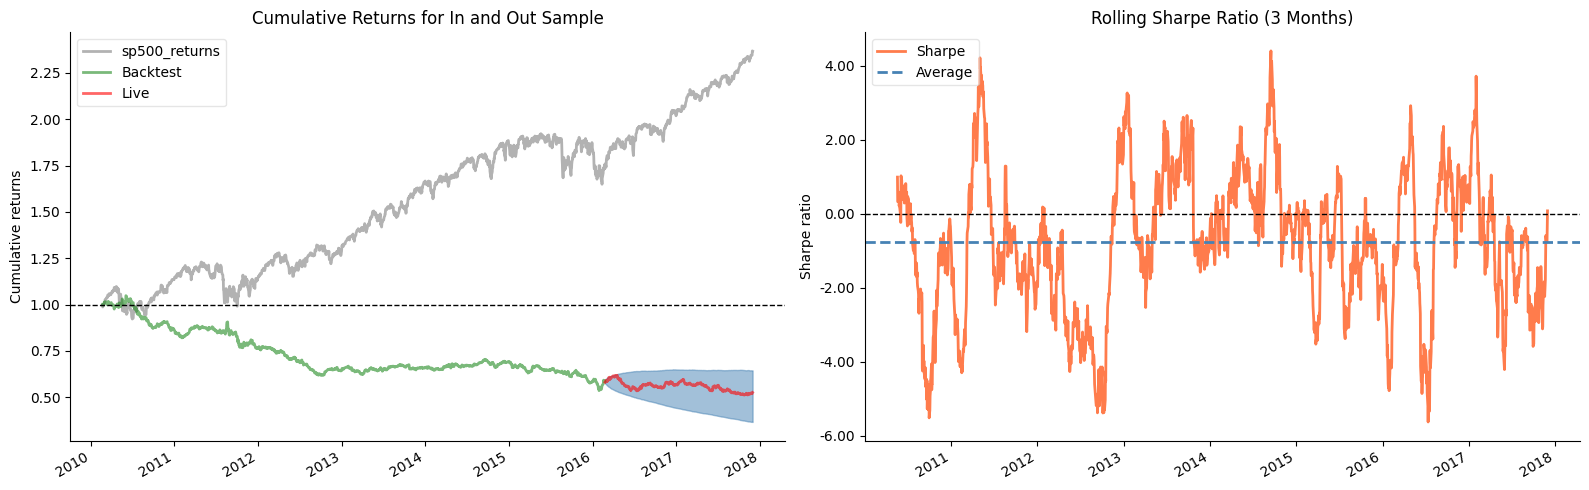

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,51.12,2010-06-04,2017-10-23,NaT,NaN
1,4.08,2010-03-19,2010-04-14,2010-05-18,43
2,2.38,2010-05-19,2010-05-27,2010-06-04,13
3,1.73,2010-03-04,2010-03-17,2010-03-19,12
4,0.48,2010-02-22,2010-02-25,2010-02-26,5


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.06%,-2.99%,3.52%
Fukushima,0.08%,-0.60%,1.05%
EZB IR Event,-0.10%,-1.19%,1.05%
Flash Crash,0.01%,-1.58%,1.20%
Apr14,0.03%,-1.58%,1.30%
Oct14,-0.20%,-1.25%,1.11%
Fall2015,-0.10%,-2.24%,2.03%
Recovery,-0.06%,-3.41%,4.04%
New Normal,-0.01%,-2.30%,3.35%


Top 10 long positions of all time,max
sid,
NVDA,19.11%
VRSK,14.17%
ALGN,13.75%
HUM,13.44%
DECK,13.22%
FFIV,10.87%
TER,10.77%
CI,10.75%
MDT,10.27%


Top 10 short positions of all time,max
sid,
NVDA,-24.15%
VRSK,-19.05%
ACN,-15.58%
ARE,-15.30%
JCI,-15.23%
VRTX,-15.13%
CNC,-14.79%
WSM,-14.41%
NRG,-13.92%


Top 10 positions of all time,max
sid,
NVDA,24.15%
VRSK,19.05%
ACN,15.58%
ARE,15.30%
JCI,15.23%
VRTX,15.13%
CNC,14.79%
WSM,14.41%
NRG,13.92%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-443225.81,$-853546.58,$410320.76
Gross profit,$11871371.61,$5874234.00,$5997137.61
Gross loss,$-12314597.42,$-6727780.57,$-5586816.85
Profit factor,$0.96,$0.87,$1.07
Avg. trade net profit,$-5.93,$-23.96,$10.48
Avg. winning trade,$323.49,$350.47,$300.80
Avg. losing trade,$-325.65,$-358.91,$-292.95
Ratio Avg. Win:Avg. Loss,$0.99,$0.98,$1.03
Largest winning trade,$21748.22,$20102.81,$21748.22
Largest losing trade,$-16862.35,$-12236.40,$-16862.35


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:58:18.563775441,1 days 14:05:07.739676033,1 days 11:57:31.429042061
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,203 days 00:00:00,184 days 00:00:00,203 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.04%
Avg returns losing,-0.05%,-0.05%,-0.04%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.02%,0.03%,0.02%
Median returns losing,-0.02%,-0.03%,-0.02%
Largest winning trade,3.40%,2.88%,3.40%
Largest losing trade,-2.49%,-1.86%,-2.49%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.01%,-0.00%,-0.02%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.02%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,-0.01%,0.00%,-0.01%,0.01%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,0.00%,0.01%,-0.02%,0.01%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.01%,0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.02%,-0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.03%,-0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.00%,-0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.02%,-0.02%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.00%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,0.00%,0.01%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.02%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.02%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,0.00%,0.0

Profitability (PnL / PnL total) per name,
symbol,
LVS,9.35%
AMD,8.19%
ALGN,8.16%
FCX,6.99%
MU,6.96%
DLTR,5.14%
KO,5.14%
SMCI,4.99%
STZ,4.80%


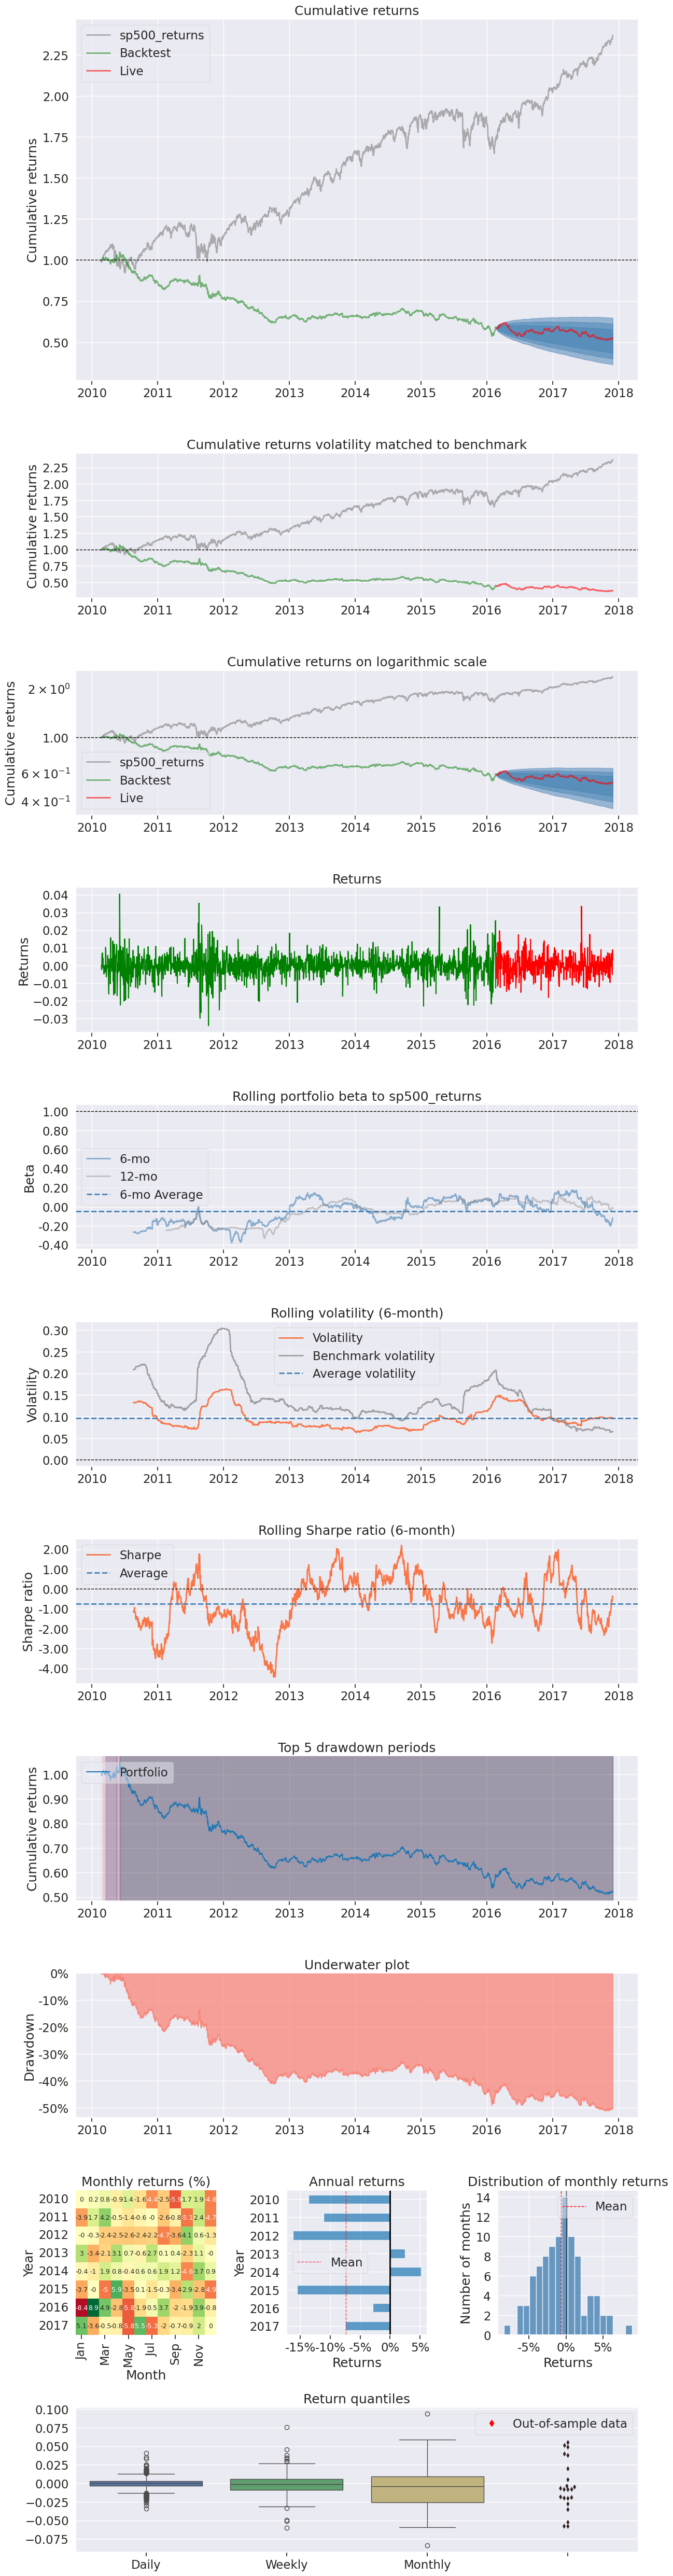

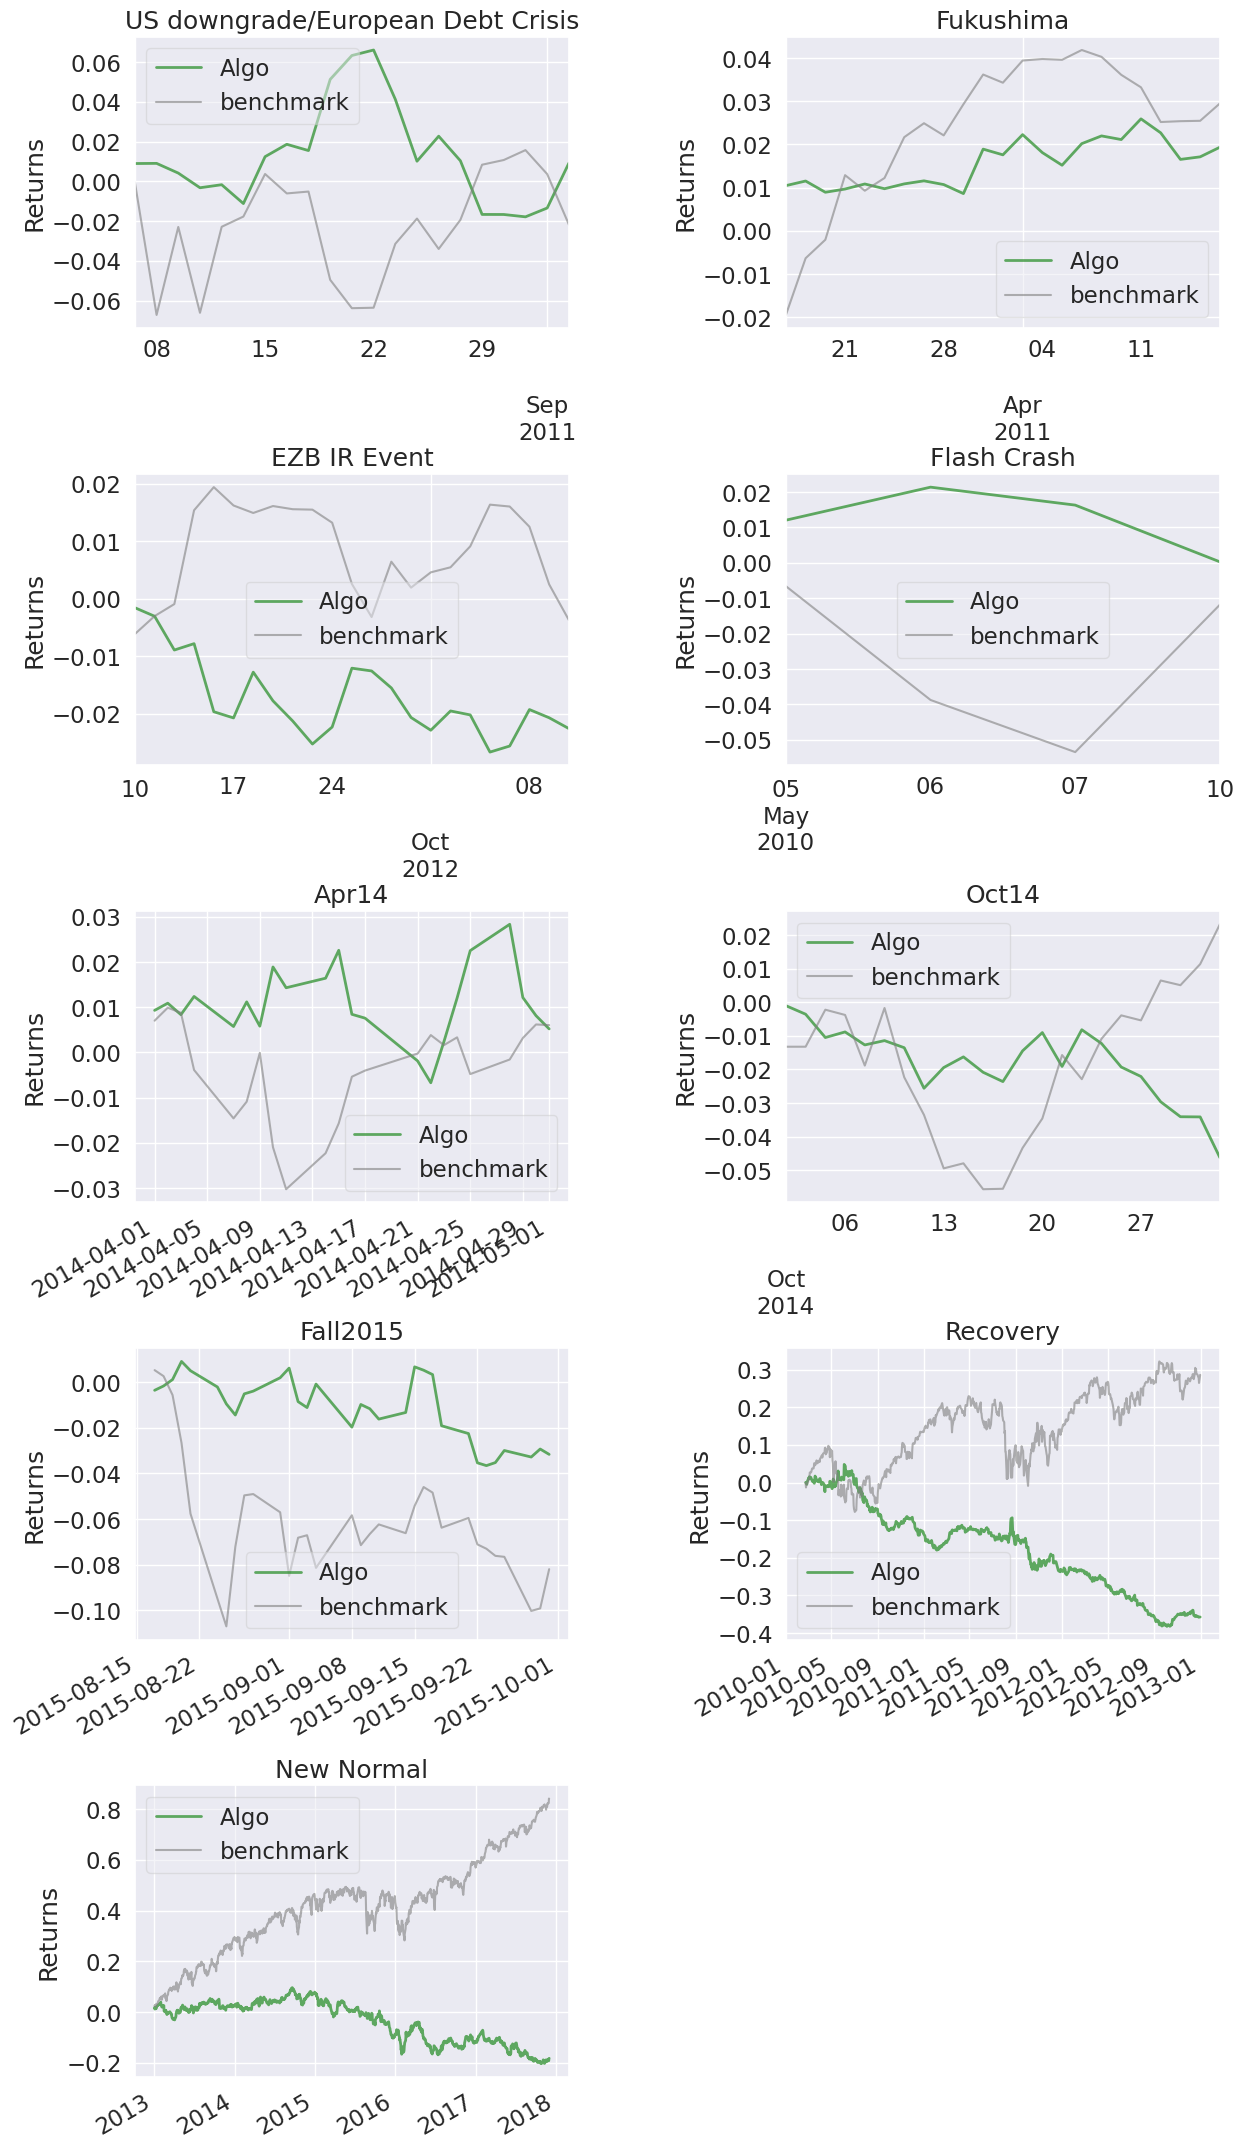

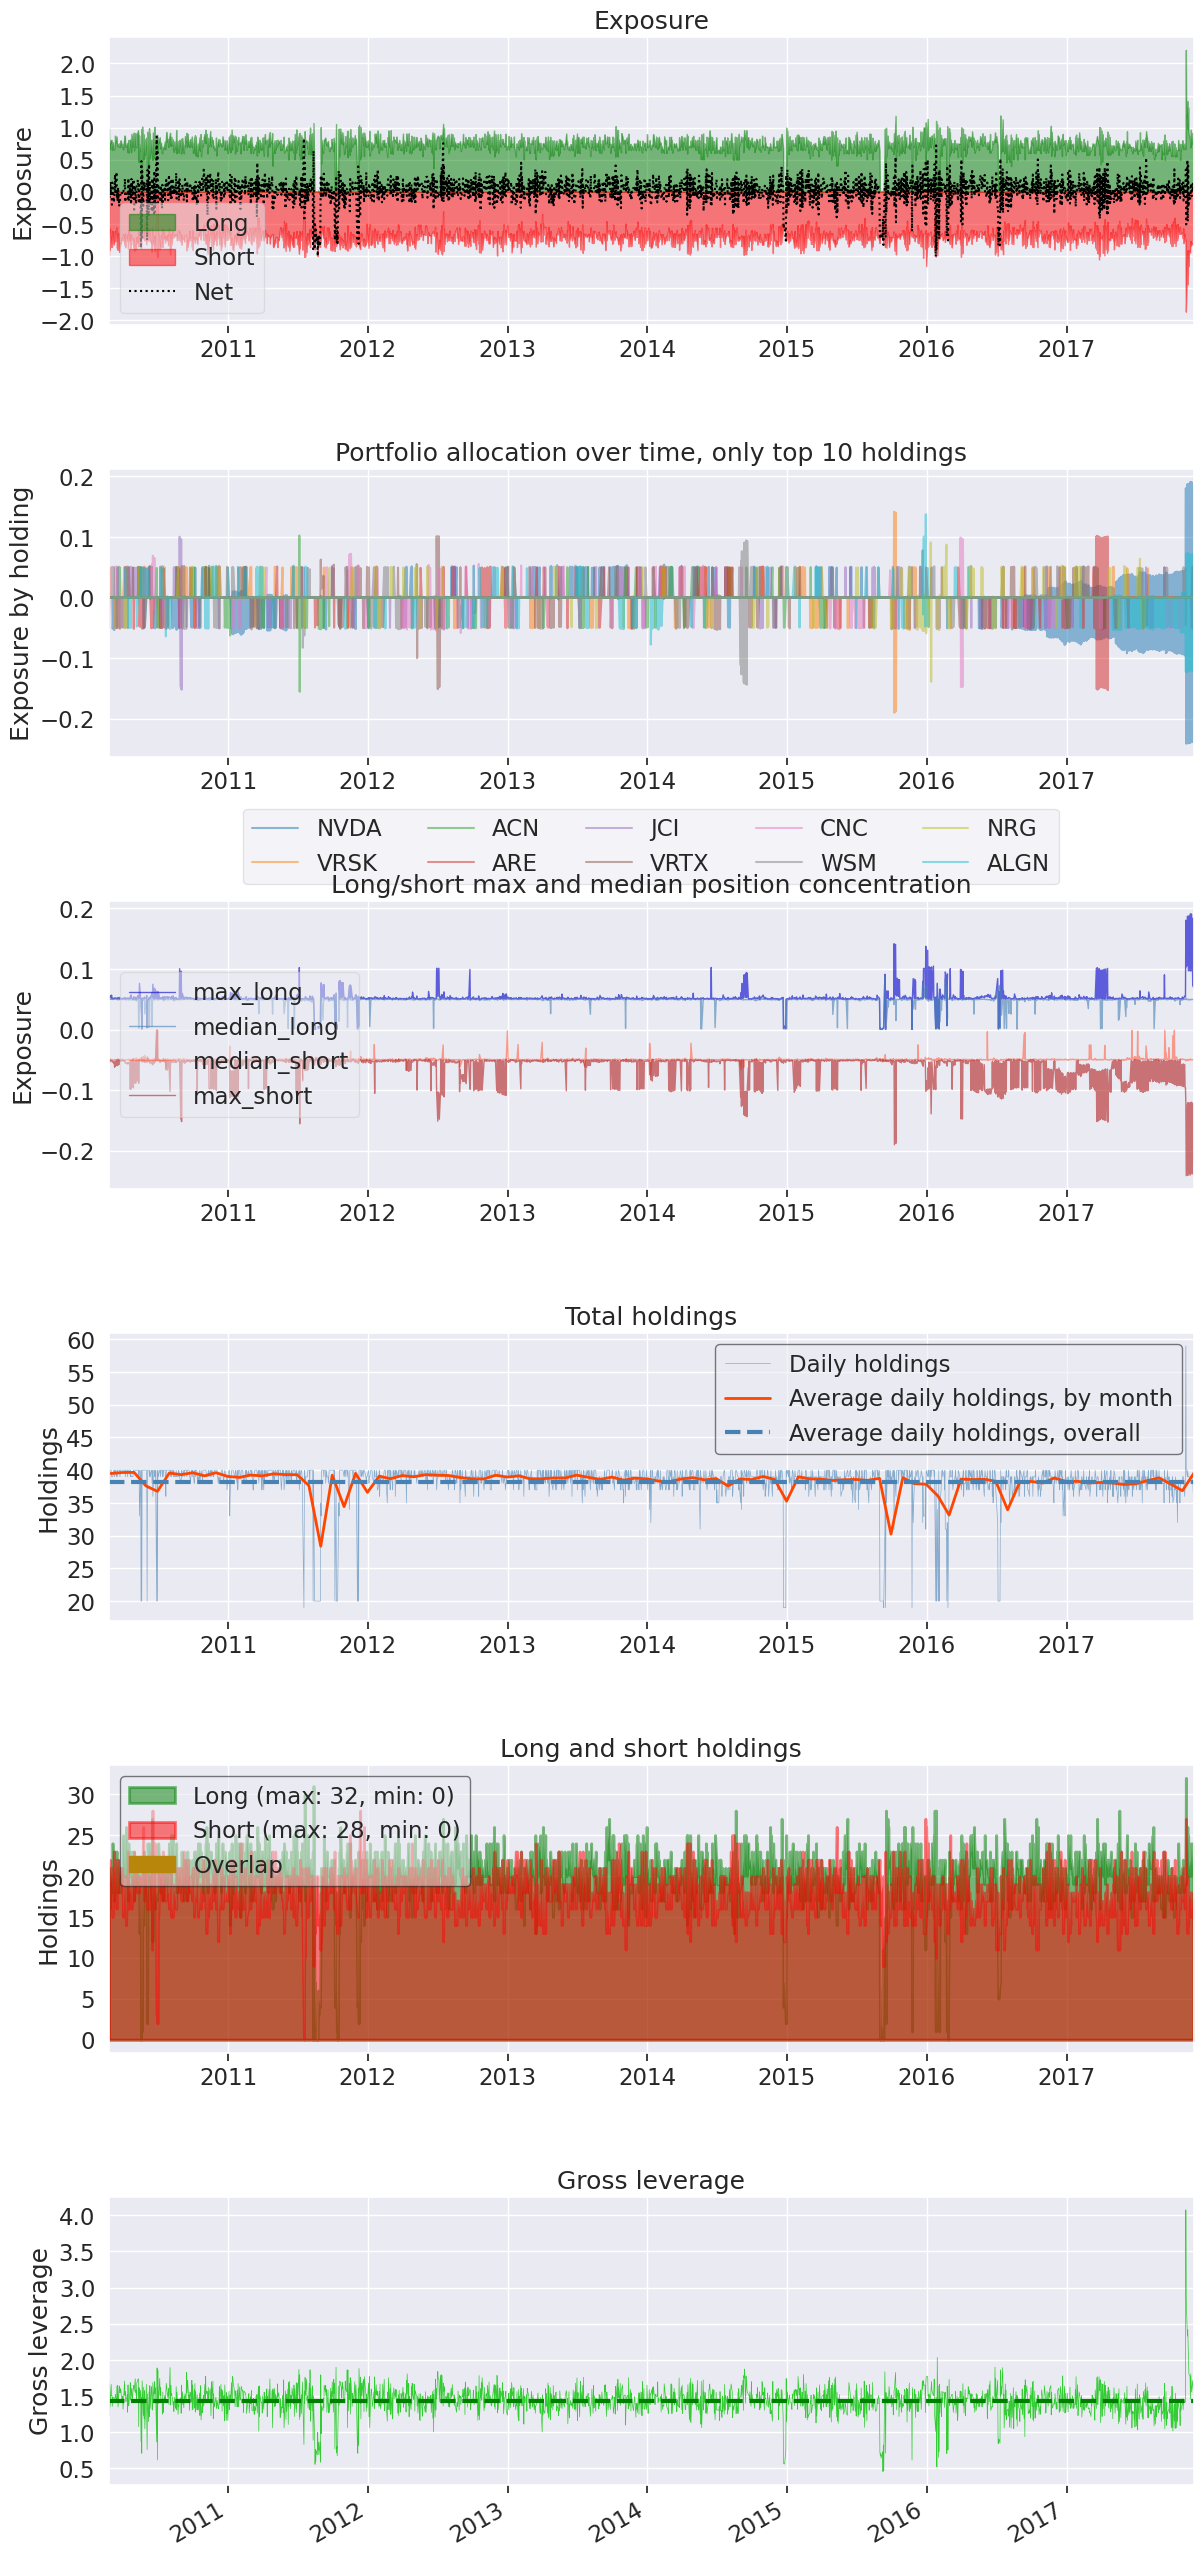

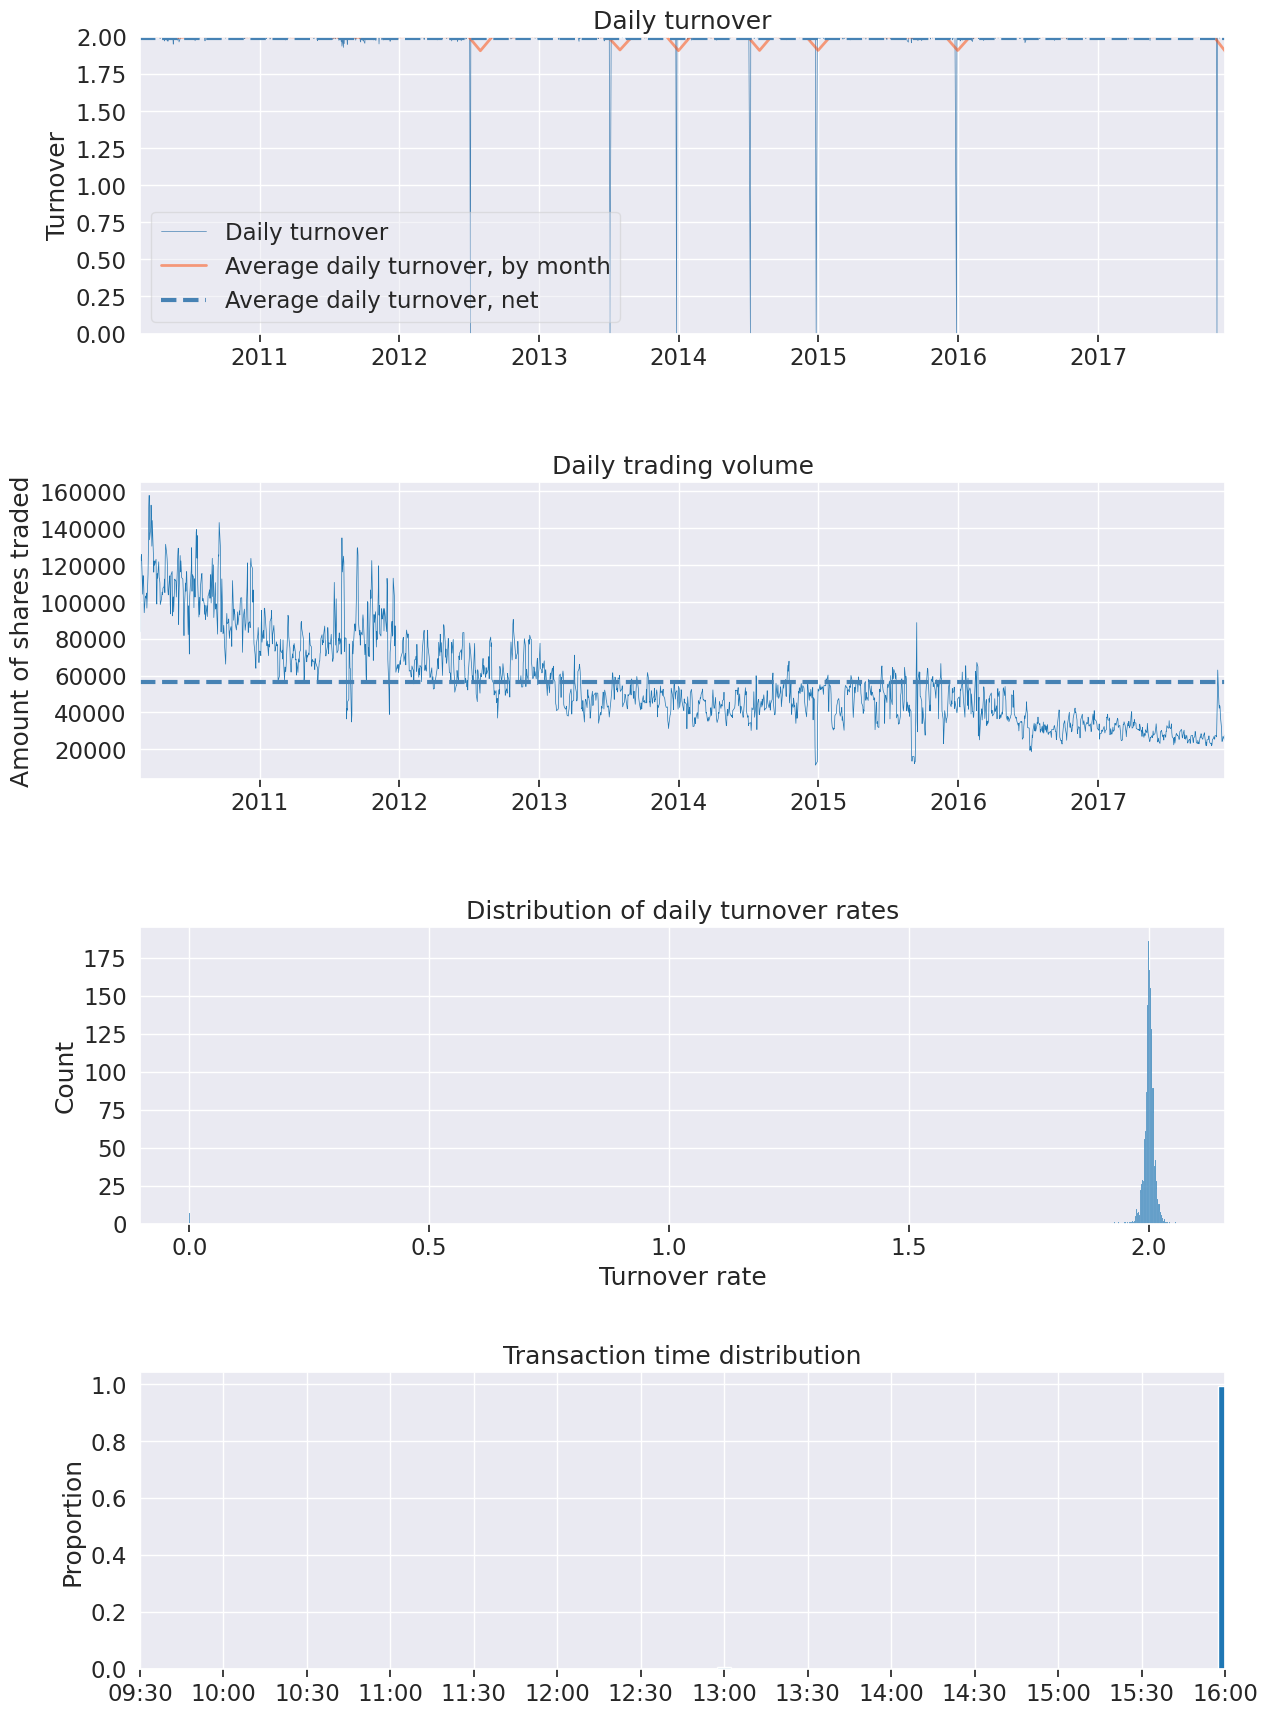

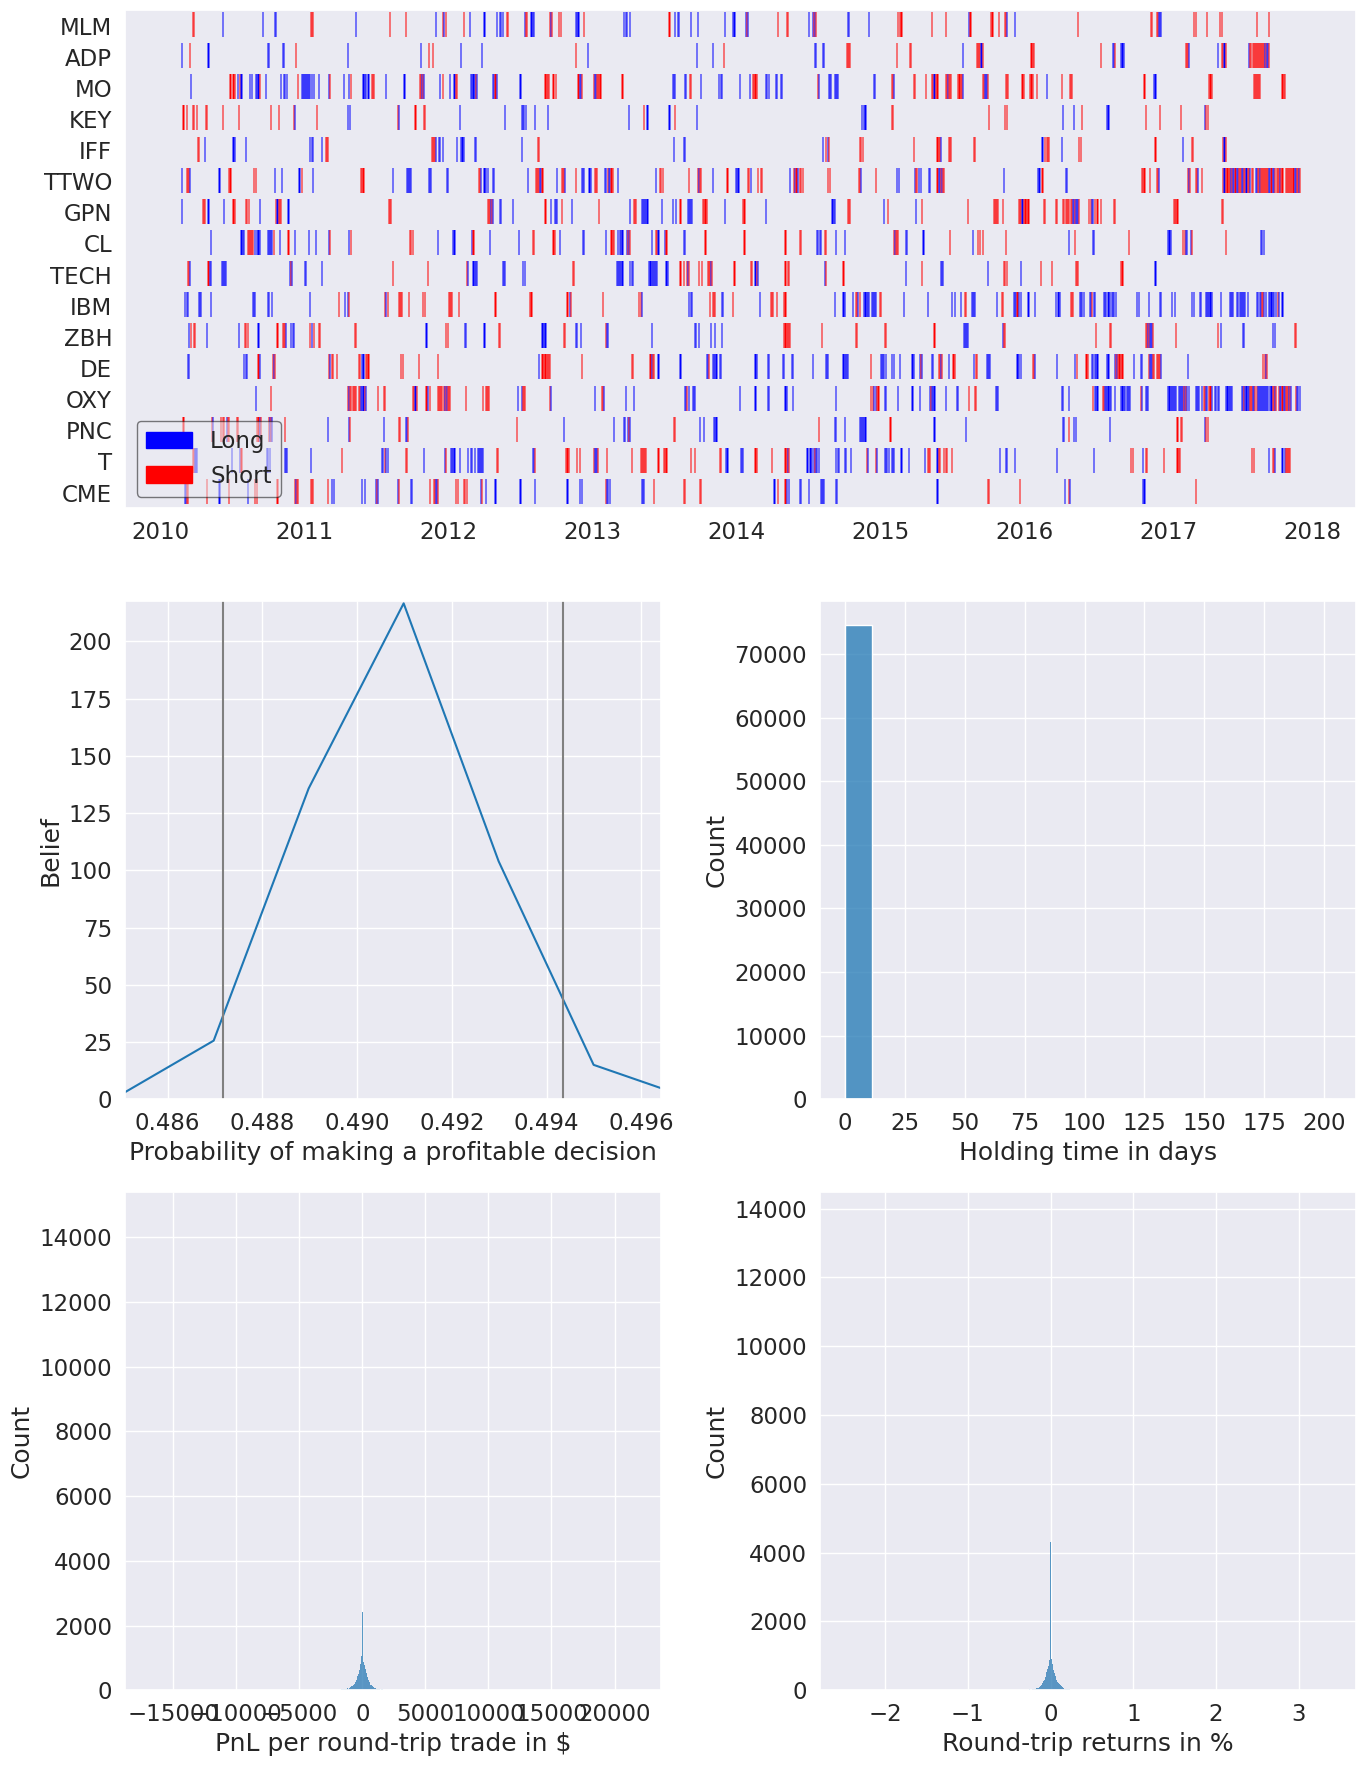

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Ridge Model-18 (alpha=50000), we will long factors in quantile-1 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":1,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge18_factor",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

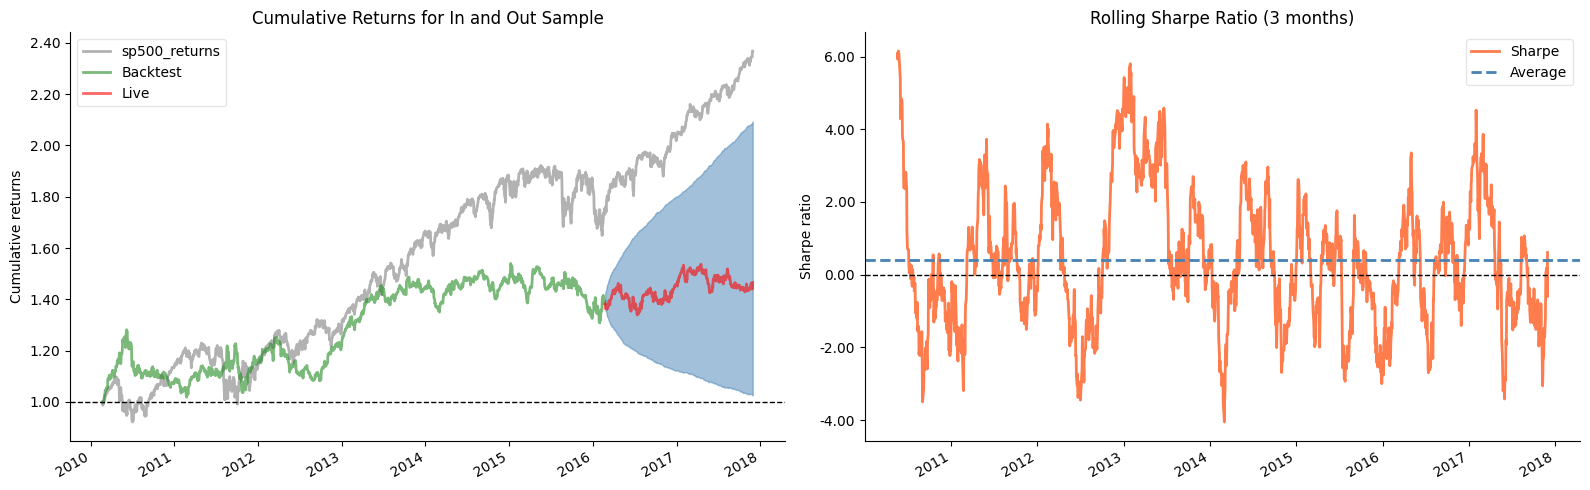

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,20.52,2010-06-07,2011-02-23,2013-01-16,683
1,15.03,2015-01-08,2016-02-01,NaT,NaN
2,9.16,2013-10-18,2014-03-03,2014-08-01,206
3,7.48,2014-09-05,2014-11-05,2015-01-07,89
4,5.21,2013-06-21,2013-07-29,2013-09-11,59


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.10%,-4.09%,4.65%
Fukushima,0.03%,-0.91%,1.07%
EZB IR Event,0.12%,-1.58%,1.28%
Flash Crash,0.13%,-1.57%,1.32%
Apr14,0.06%,-1.54%,1.33%
Oct14,-0.22%,-1.70%,1.75%
Fall2015,-0.01%,-2.52%,2.70%
Recovery,0.03%,-4.55%,4.68%
New Normal,0.02%,-2.52%,3.43%


Top 10 long positions of all time,max
sid,
PODD,33.85%
PHM,33.75%
MOS,27.39%
CPB,26.97%
SLB,26.78%
WST,25.10%
STLD,24.23%
GD,22.92%
HRL,22.48%


Top 10 short positions of all time,max
sid,
SLB,-31.94%
PODD,-28.83%
MGM,-27.07%
PHM,-26.14%
AMD,-24.24%
MOS,-22.69%
CI,-21.78%
CNP,-21.63%
CPB,-21.43%


Top 10 positions of all time,max
sid,
PODD,33.85%
PHM,33.75%
SLB,31.94%
MOS,27.39%
MGM,27.07%
CPB,26.97%
WST,25.10%
AMD,24.24%
STLD,24.23%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$537244.28,$-849552.01,$1386796.28
Gross profit,$20817095.27,$9699477.03,$11117618.24
Gross loss,$-20279850.99,$-10549029.03,$-9730821.96
Profit factor,$1.03,$0.92,$1.14
Avg. trade net profit,$8.52,$-28.96,$41.14
Avg. winning trade,$662.48,$690.01,$640.19
Avg. losing trade,$-651.27,$-699.68,$-605.83
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.06
Largest winning trade,$49343.22,$41654.24,$49343.22
Largest losing trade,$-31639.41,$-24927.00,$-31639.41


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:02:10.634920383,1 days 13:34:37.545841854,1 days 10:41:43.084895586
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,138 days 23:00:00,138 days 23:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.05%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,3.40%,3.02%,3.40%
Largest losing trade,-2.59%,-1.87%,-2.59%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.01%,-0.02%,0.02%,-0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.02%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.02%,0.02%,0.00%,-0.00%,0.00%,0.02%,-0.00%,0.01%,0.00%,-0.01%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,0.01%,0.00%,0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.02%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,0.01%,-0.01%,0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.01%,-0.02%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.02%,-0.01%,-0.01%,0.02%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.02%,-0.00%,0.00%,-0.01%,0.00%,0.01%,0.02%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,0.01%,0.01%,-0.01%,0.00%,-0.02%,0.00%,0.00%,0.00%,0.00%,-0.02%,0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,-0.01%,0.01%,0.01%,-0.00%,0.00%,-0.01%,0.00%,0.02%,-0.01%,0.00%,0.00%,0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.02%,0.02%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.00%
Avg returns winning,0

Profitability (PnL / PnL total) per name,
symbol,
SWKS,11.24%
PODD,8.18%
MNST,8.17%
BLDR,7.95%
BSX,7.77%
EA,7.53%
MGM,7.51%
STLD,6.91%
REGN,6.25%


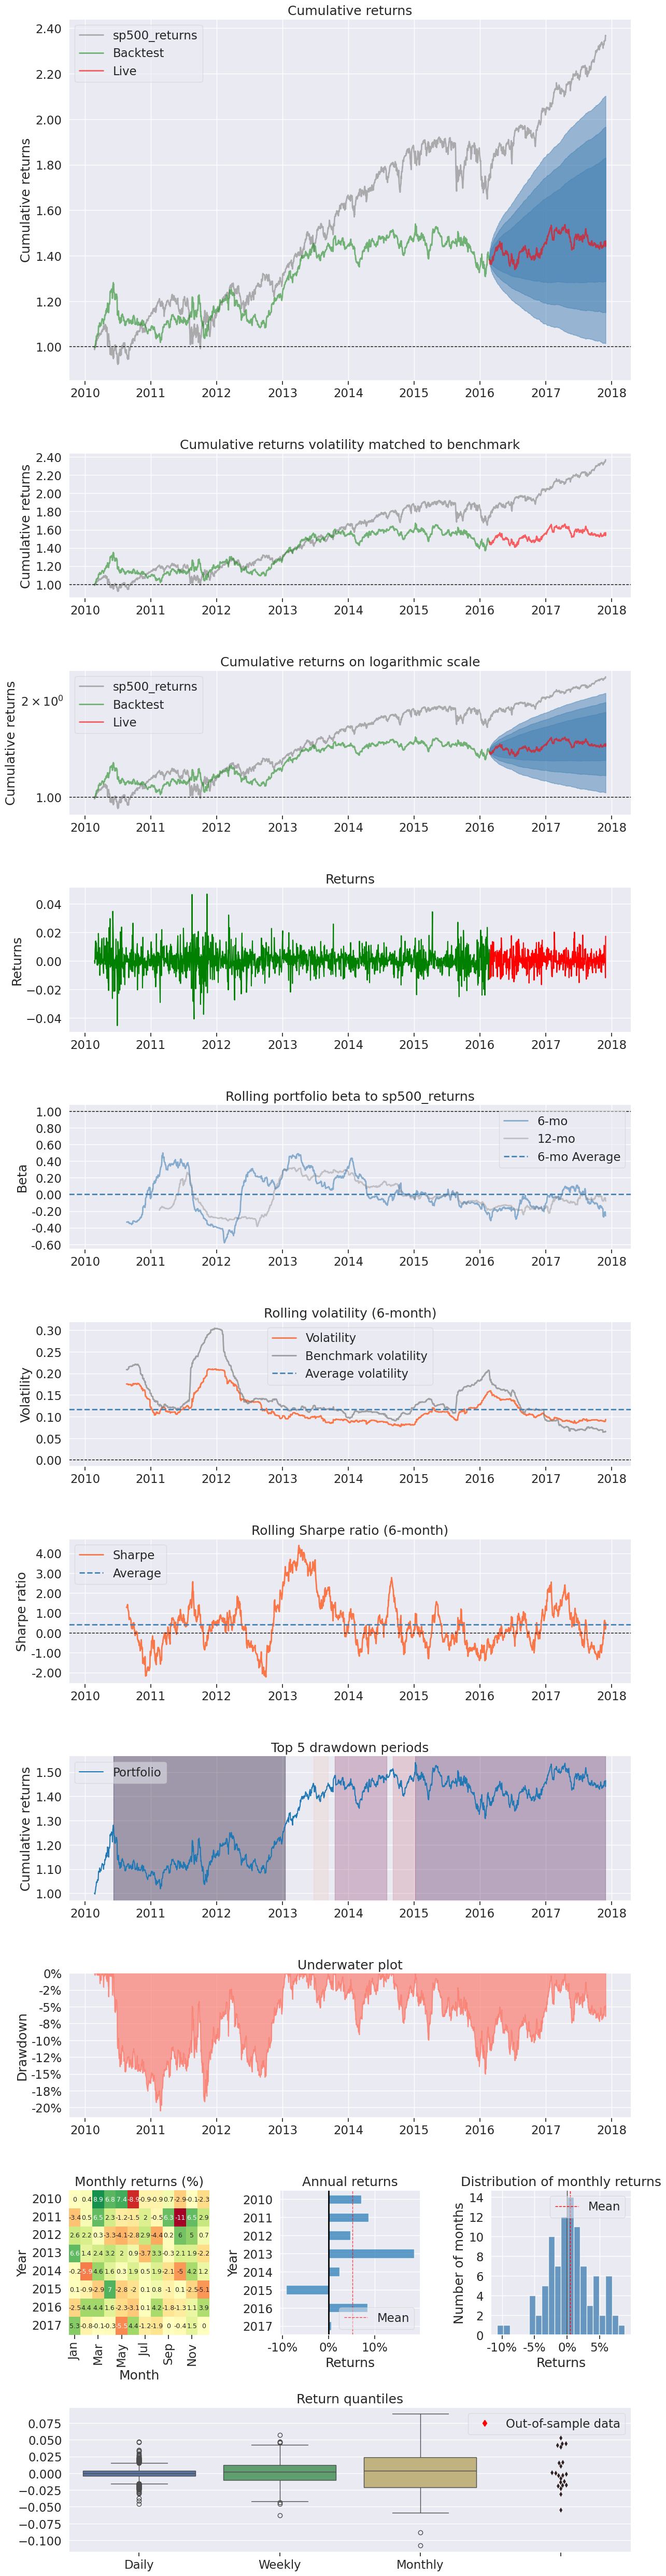

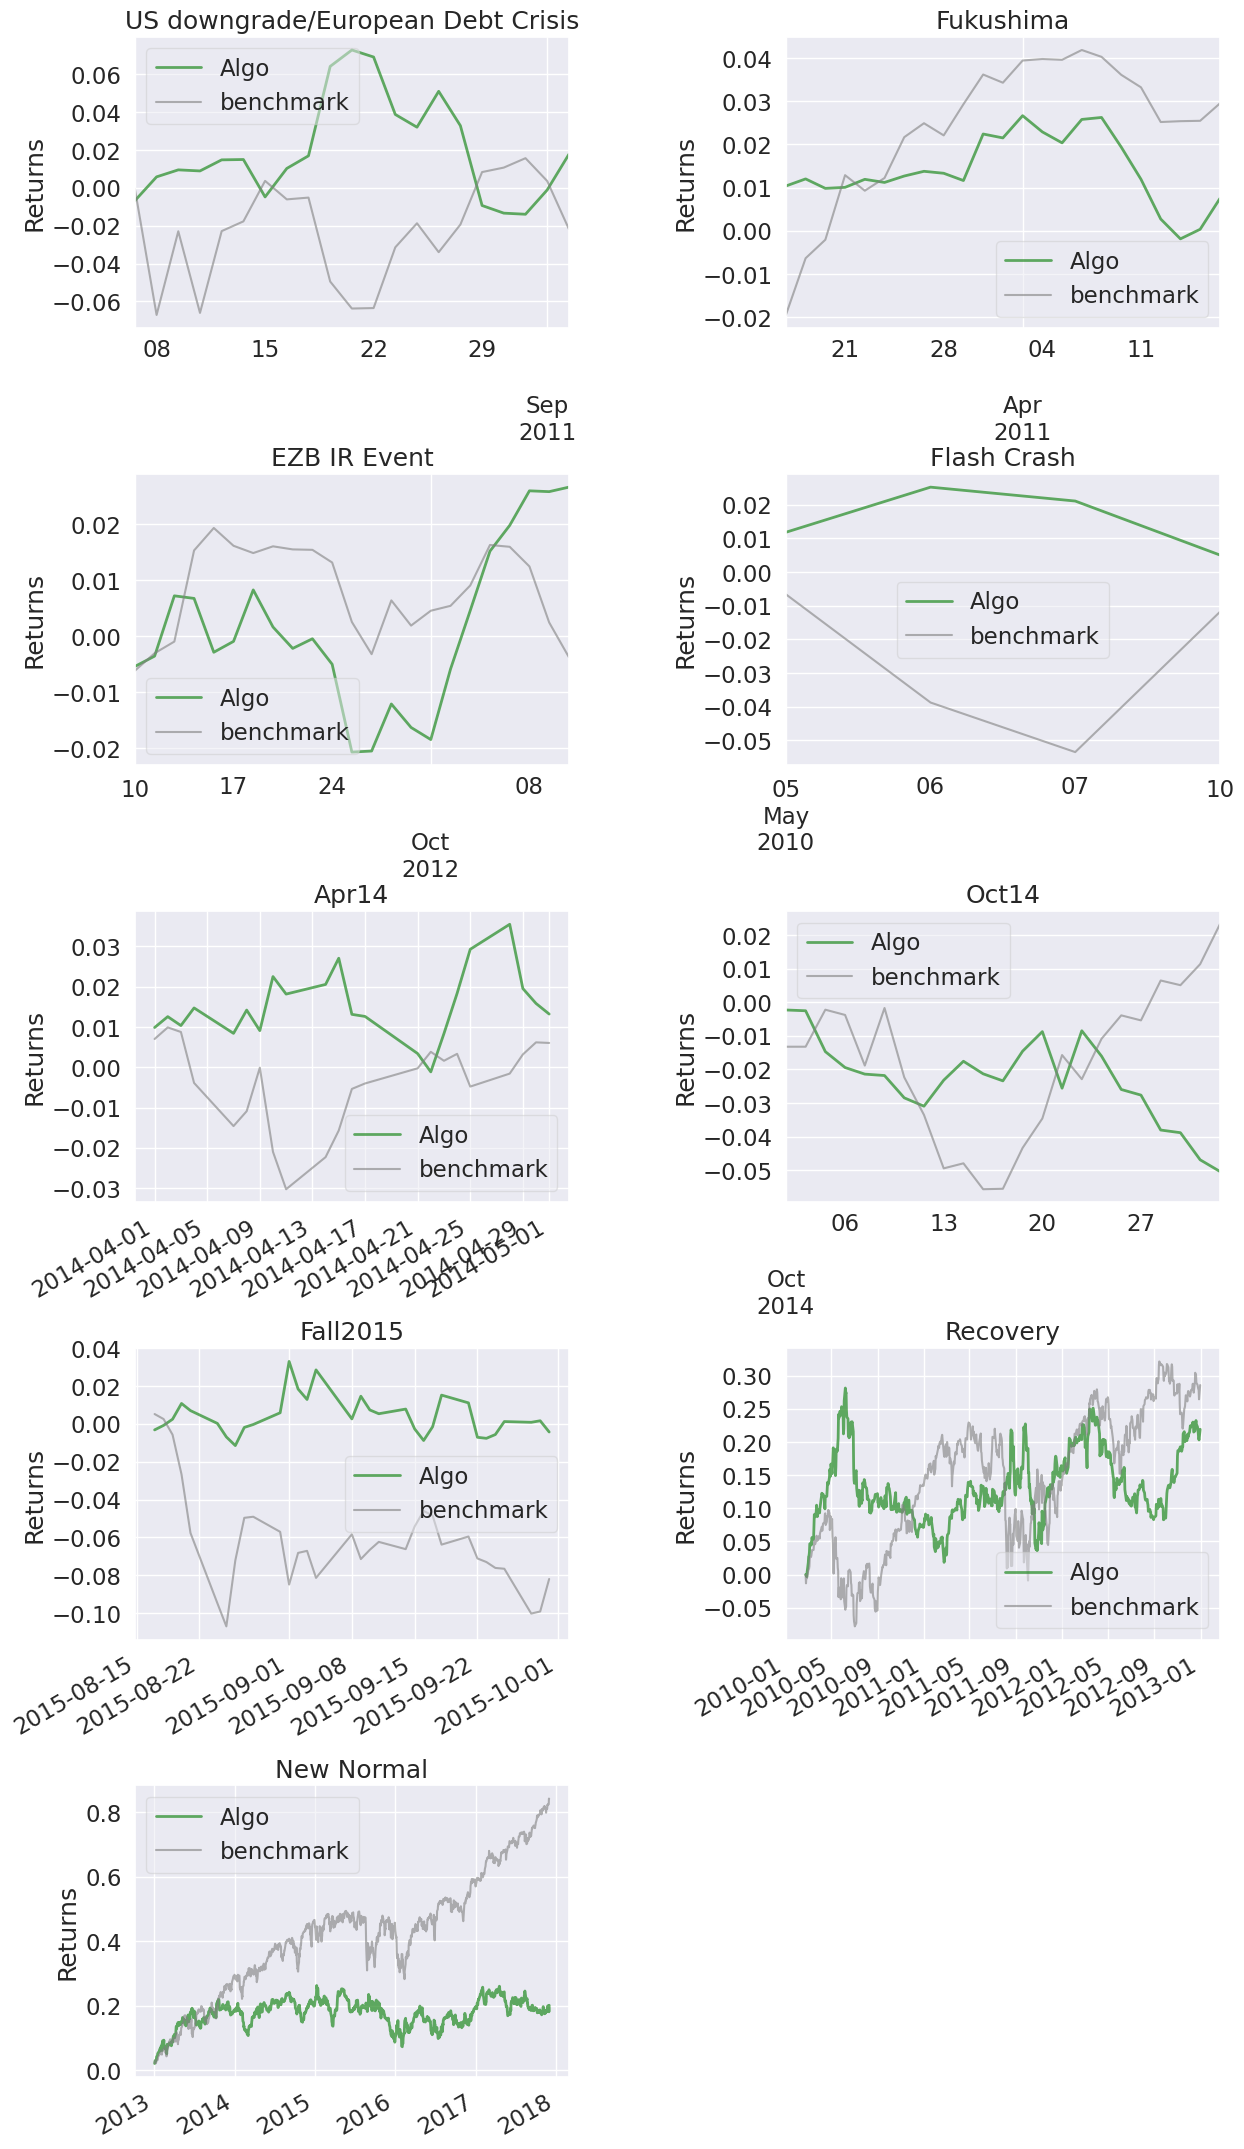

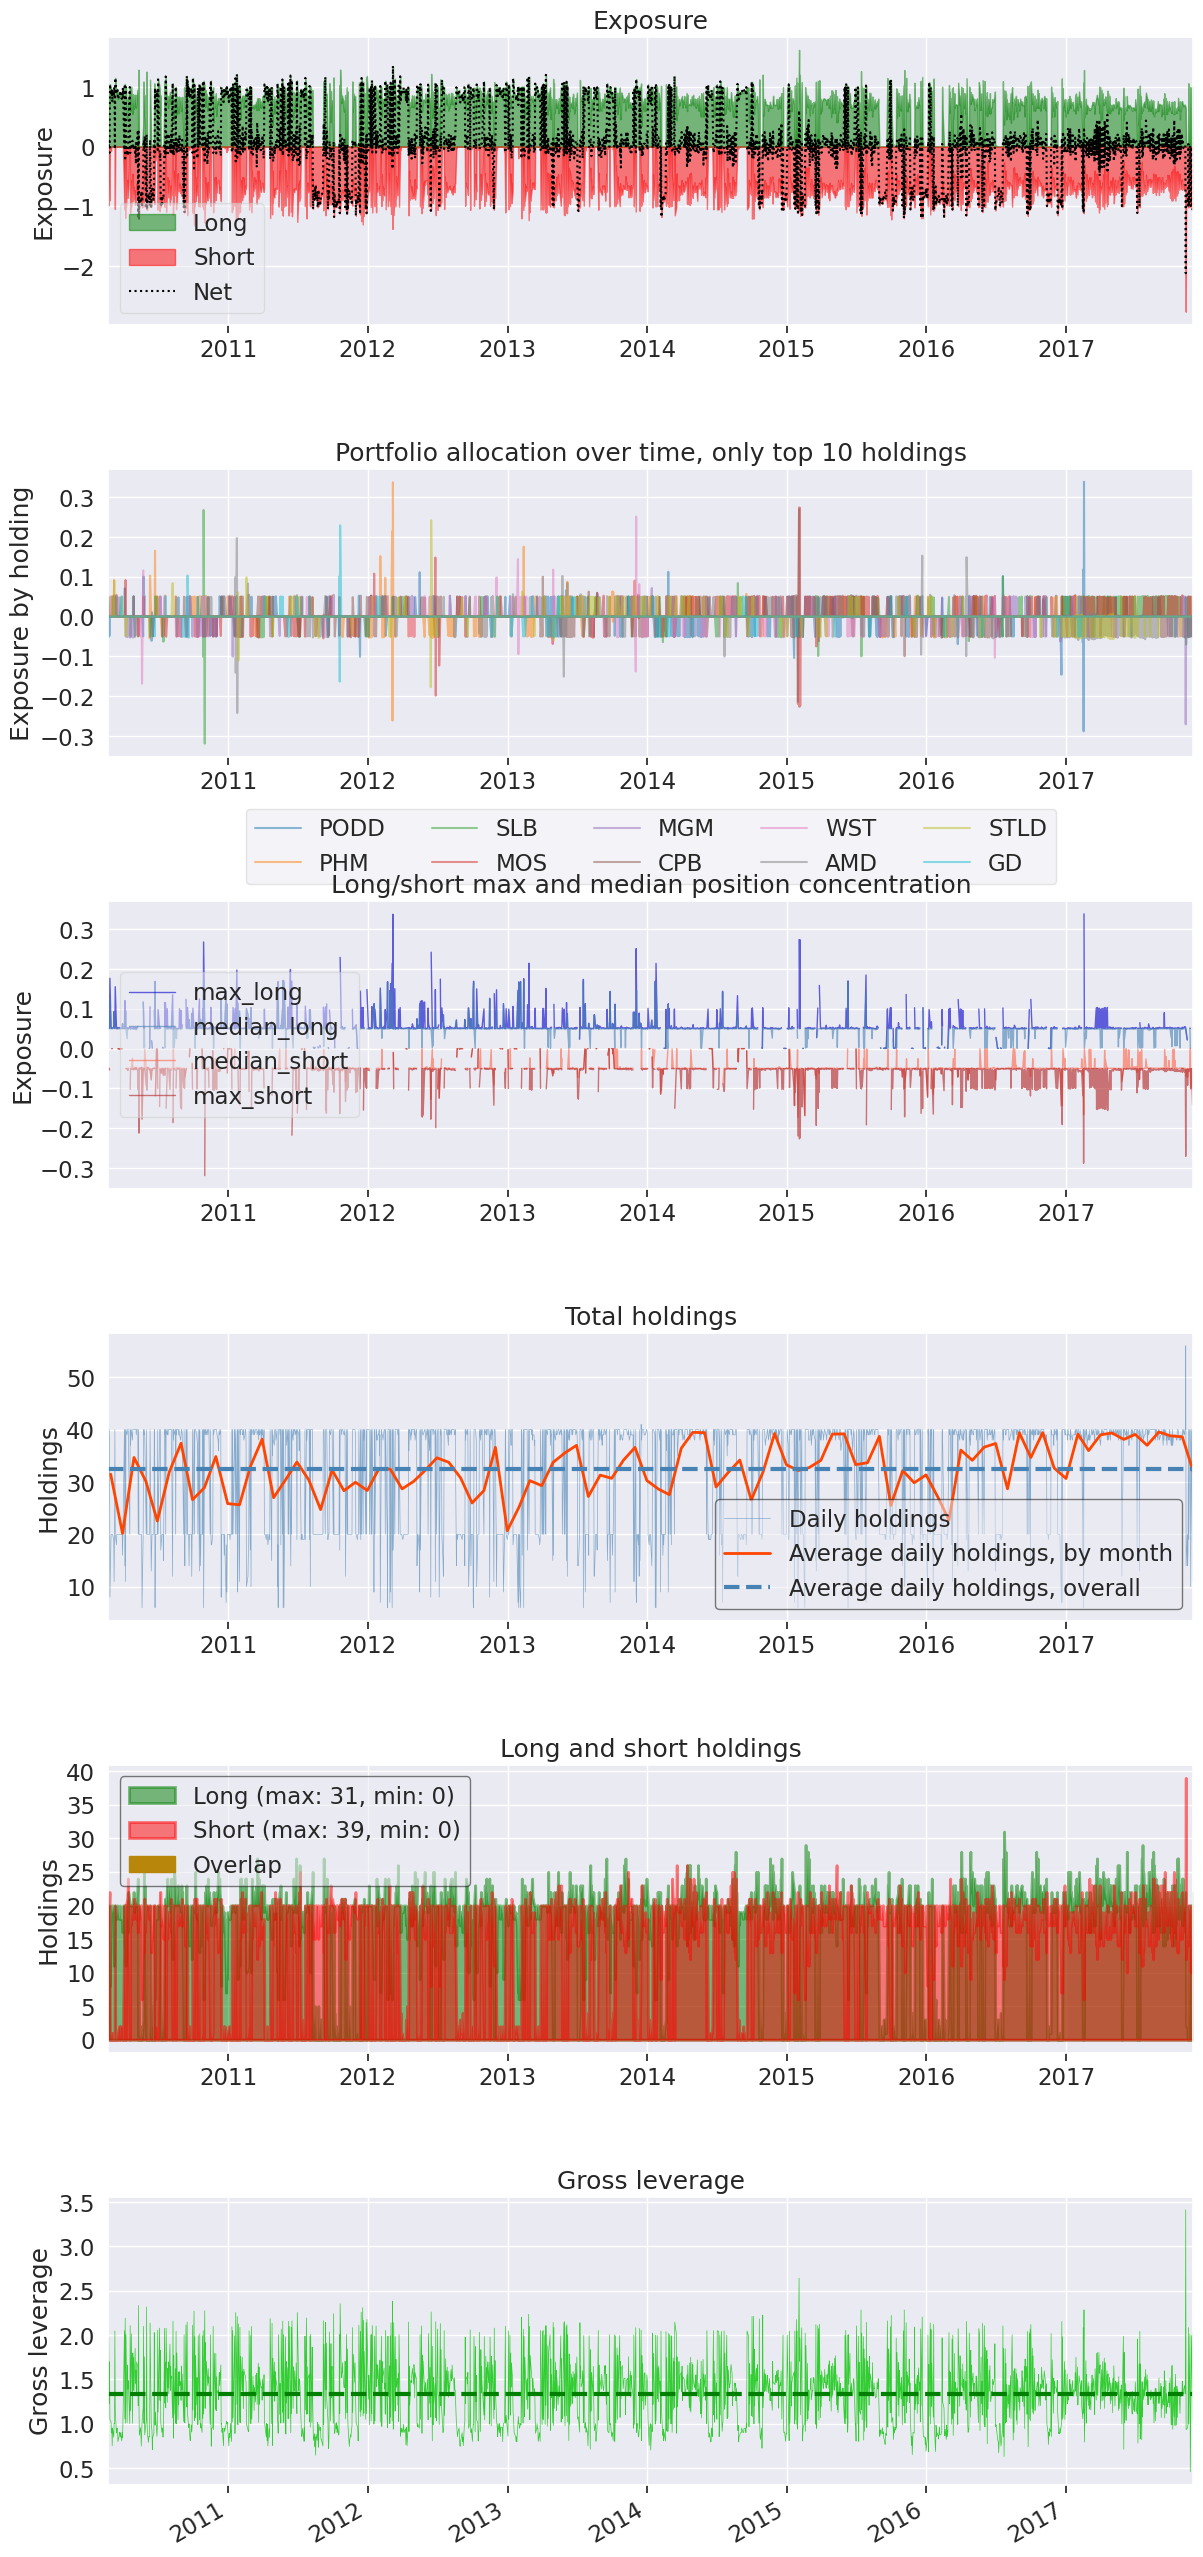

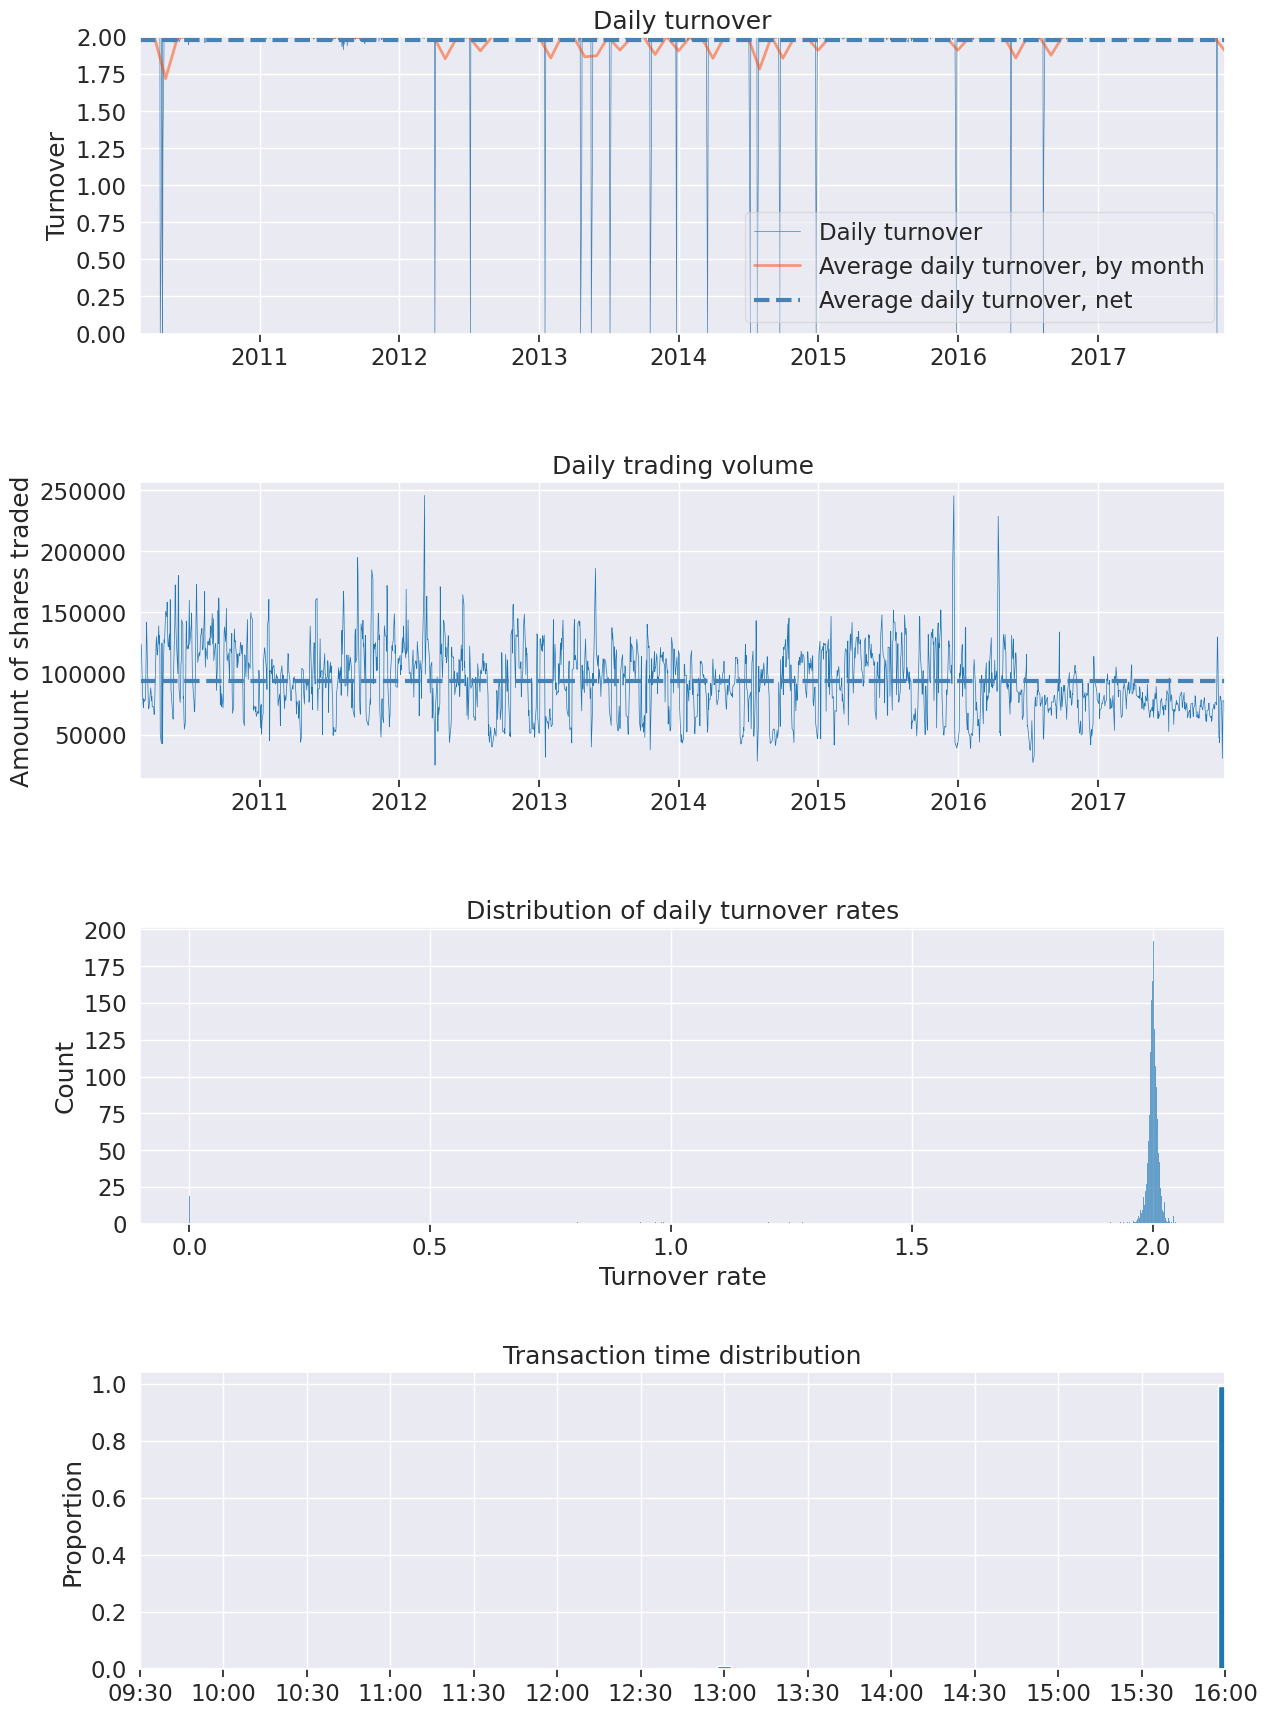

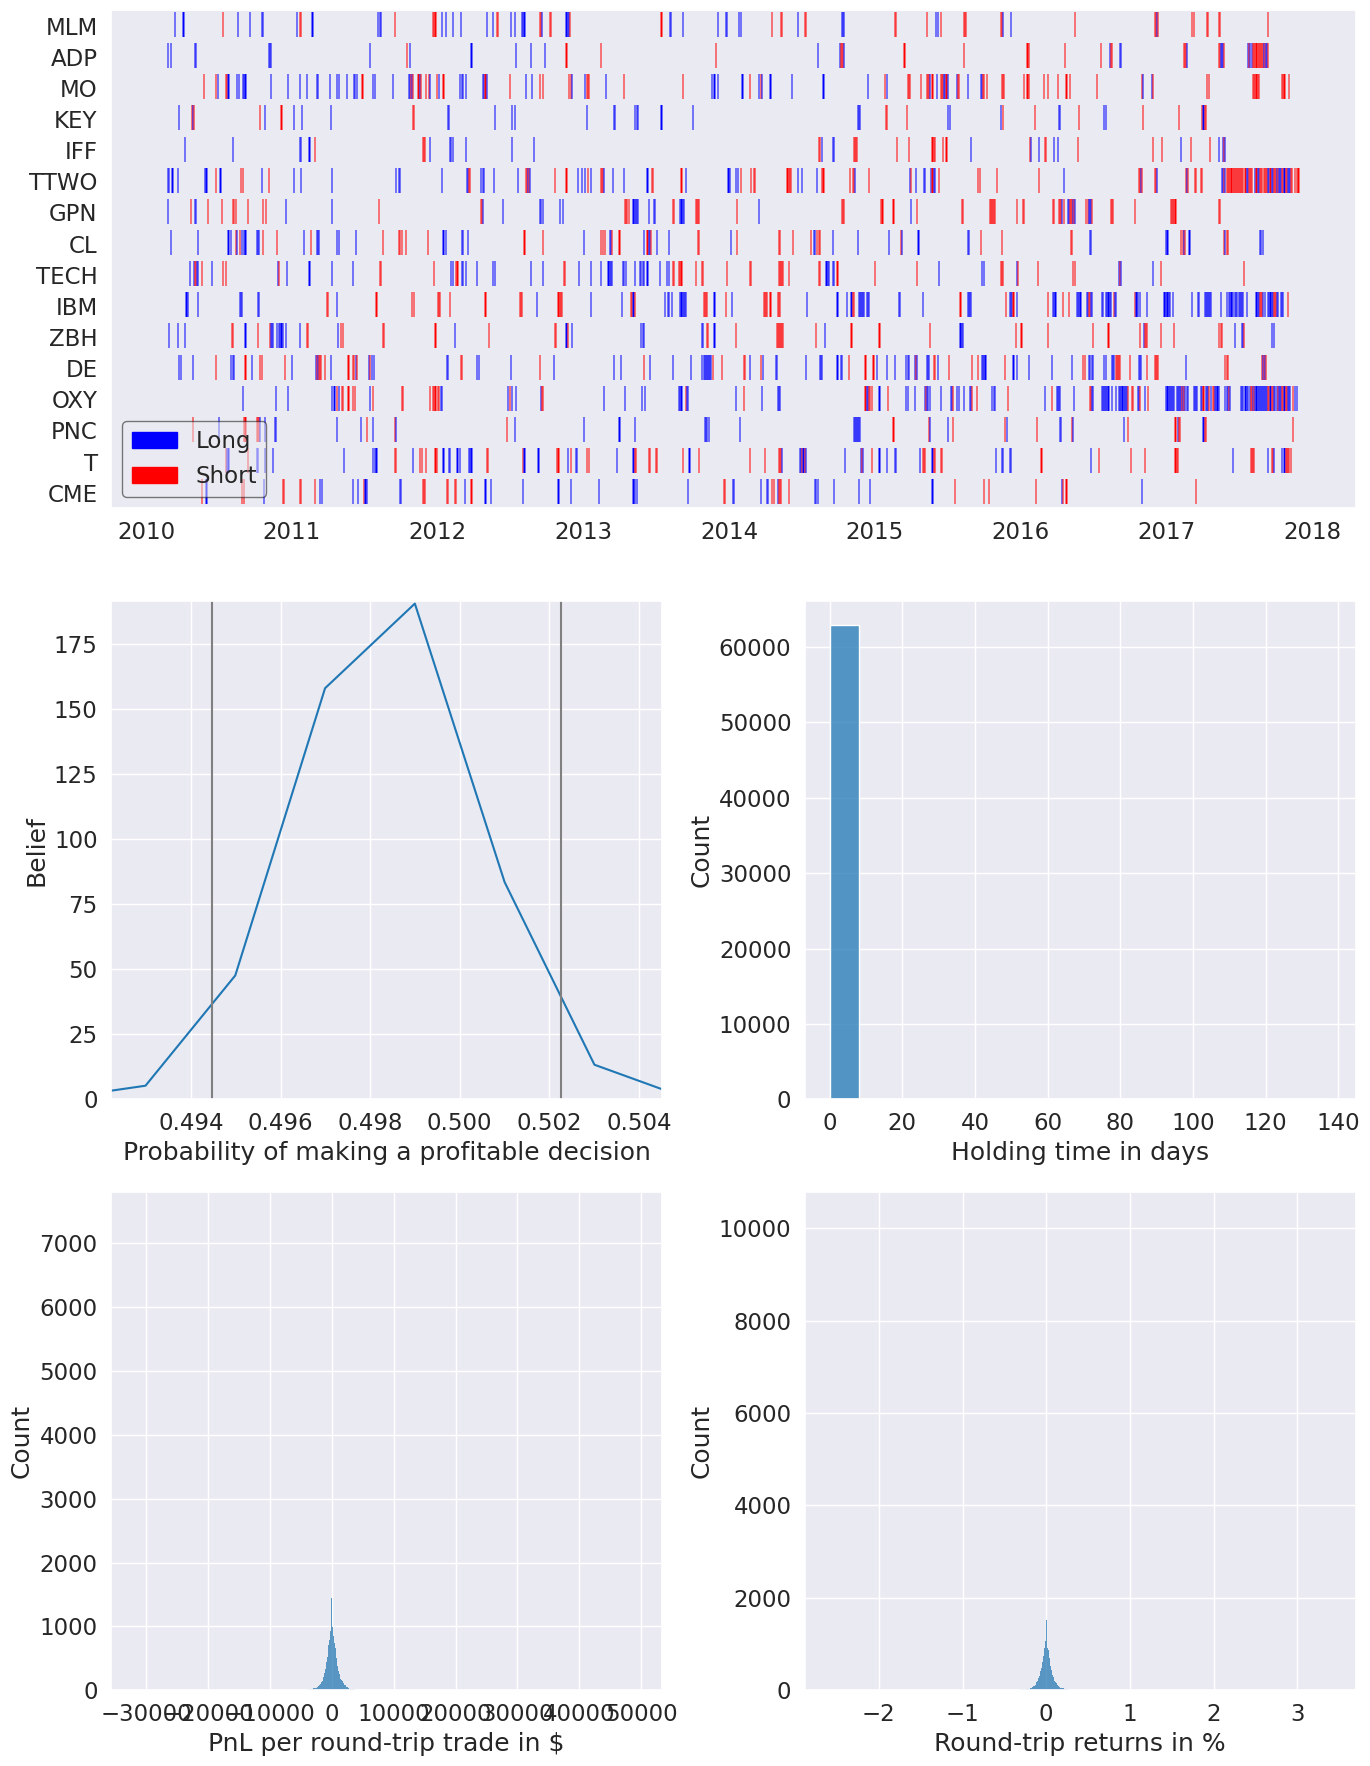

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)